Task #1: Tweet Emotions’ Classification

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import set_random_seed

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Datasets/tweet_emotions.csv")

Preproccessing

In [4]:
df.head(5)

,Id,Tweet,Label
0,145353048817012000,Thinks that @melbahughes had a great 50th birt...,surprise
1,144279638024257000,"Como una expresiÃ³n tan simple, una sola oraci...",sadness
2,140499585285111000,the moment when you get another follower and y...,joy
3,145207578270507000,Be the greatest dancer of your life! practice ...,joy
4,139502146390470000,eww.. my moms starting to make her annual rum ...,disgust


In [5]:
print(df["Label"][0])
print("-"*60)
print(df["Tweet"][0])

surprise
------------------------------------------------------------
Thinks that @melbahughes had a great 50th birthday party :) 


In [6]:
df.groupby("Label").count()

,Id,Tweet
Label,,
anger,1555,1555
disgust,761,761
fear,2816,2816
joy,8240,8240
sadness,3830,3830
surprise,3849,3849


In [7]:
tweet = df["Tweet"].values
label = df["Label"].values

In [8]:
#Convert categorical variable into dummy/indicator variables.
Y = pd.get_dummies(label).values
Y.shape

(21051, 6)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    tweet, Y,
    test_size=0.2,
    random_state=42,
    stratify=label
)

In [10]:
max_words = 10000
tokenizer = Tokenizer(num_words=max_words)

In [11]:
# training data preparation
tokenizer.fit_on_texts(X_train)
word_index = tokenizer.word_index

# Convert tweets into 0-1 values
X_train = tokenizer.texts_to_matrix(X_train, mode='binary').astype('float32')
X_test = tokenizer.texts_to_matrix(X_test, mode='binary').astype('float32')

In [12]:
X_train.shape, X_test.shape

((16840, 10000), (4211, 10000))

In [13]:
word_index

{'the': 1,
 'i': 2,
 'to': 3,
 'a': 4,
 'my': 5,
 'and': 6,
 'of': 7,
 'in': 8,
 'is': 9,
 'you': 10,
 'for': 11,
 'it': 12,
 'me': 13,
 'that': 14,
 'on': 15,
 'have': 16,
 'quot': 17,
 'with': 18,
 'be': 19,
 'this': 20,
 'not': 21,
 'just': 22,
 'so': 23,
 'at': 24,
 "i'm": 25,
 'your': 26,
 'amp': 27,
 'up': 28,
 'when': 29,
 'all': 30,
 'love': 31,
 'today': 32,
 'but': 33,
 'day': 34,
 'out': 35,
 'now': 36,
 'time': 37,
 'tomorrow': 38,
 'was': 39,
 'get': 40,
 'like': 41,
 'are': 42,
 "don't": 43,
 'no': 44,
 'one': 45,
 'do': 46,
 'christmas': 47,
 'we': 48,
 'from': 49,
 'will': 50,
 'what': 51,
 'work': 52,
 'about': 53,
 'go': 54,
 'an': 55,
 'back': 56,
 'going': 57,
 'they': 58,
 'people': 59,
 "it's": 60,
 'if': 61,
 'can': 62,
 'got': 63,
 'good': 64,
 'home': 65,
 '2': 66,
 'u': 67,
 'know': 68,
 'rt': 69,
 "can't": 70,
 'night': 71,
 'life': 72,
 'as': 73,
 'how': 74,
 'de': 75,
 'then': 76,
 'he': 77,
 'en': 78,
 'by': 79,
 'more': 80,
 'its': 81,
 'some': 82,
 'feel

In [14]:
X_train[100]

array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)

**Model Building : Neural Network**

In [15]:
model = Sequential()
model.add(Input(shape=(max_words,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(6, activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       640,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 642,342 (2.45 MB)

 Trainable params: 642,342 (2.45 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['acc'])

In [17]:
# 10% of the training partition is used for validation.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - acc: 0.5132 - loss: 1.3004 - val_acc: 0.5445 - val_loss: 1.1899
Epoch 2/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - acc: 0.6446 - loss: 0.9909 - val_acc: 0.5802 - val_loss: 1.1407
Epoch 3/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - acc: 0.7134 - loss: 0.8241 - val_acc: 0.5819 - val_loss: 1.1614
Epoch 4/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - acc: 0.7588 - loss: 0.6983 - val_acc: 0.5909 - val_loss: 1.1895


In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       640,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,284,686 (4.90 MB)

 Trainable params: 642,342 (2.45 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 642,344 (2.45 MB)

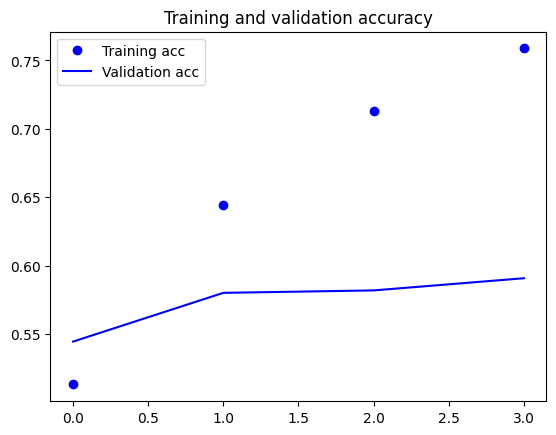

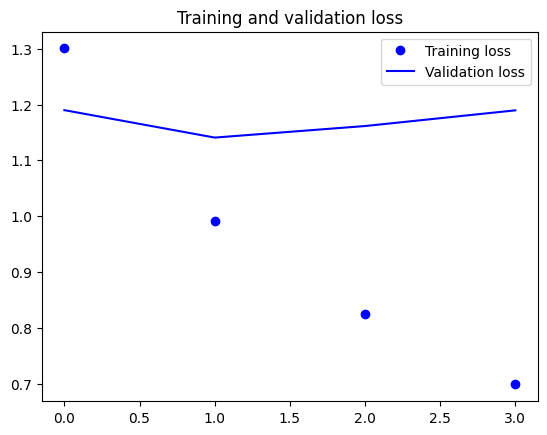

In [19]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [20]:
train_loss, train_acc = model.evaluate(X_train, y_train)
test_loss, test_acc = model.evaluate(X_test, y_test)

print('Training accuracy:', round(train_acc * 100, 2), '%')
print('Test accuracy:', round(test_acc * 100, 2), '%')

527/527 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.7192 - loss: 0.8267
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.5977 - loss: 1.1251
Training accuracy: 71.92 %
Test accuracy: 59.77 %


QUESTIONS

In [21]:
# Predictions
predictions = model.predict(X_test)

y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(
    y_true,
    y_pred,
    target_names=pd.get_dummies(df['Label']).columns,
    zero_division=0
))

132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

       anger       0.49      0.33      0.40       311
     disgust       0.46      0.08      0.13       152
        fear       0.70      0.51      0.59       563
         joy       0.66      0.80      0.72      1649
     sadness       0.47      0.52      0.49       766
    surprise       0.56      0.53      0.54       770

    accuracy                           0.60      4211
   macro avg       0.56      0.46      0.48      4211
weighted avg       0.59      0.60      0.58      4211



Inside your notebook, also answer following questions,

1. Does accuracy vary from class to class label?
```
Ans : Yes. Joy has the highest recall (80%), while disgust has
      the lowest recall (8%).
```

2. If so, write the reasons
```
Ans : The data is not balanced. Joy has more examples than disgust.
      Similar words can express different emotions, which may
      also make prediction difficult.
```

**Adding two more layers of 32 neurons**

In [22]:
set_random_seed(42)
model2 = Sequential()
model2.add(Input(shape=(max_words,)))
model2.add(Dense(64, activation='relu'))
model2.add(Dense(32, activation='relu'))
model2.add(Dense(32, activation='relu'))
model2.add(Dense(32, activation='relu'))
model2.add(Dense(6, activation='softmax'))
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │       640,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 644,454 (2.46 MB)

 Trainable params: 644,454 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model2.compile(optimizer='rmsprop',
               loss='categorical_crossentropy',
               metrics=['acc'])

early_stop2 = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history2 = model2.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop2]
)

Epoch 1/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - acc: 0.4958 - loss: 1.3323 - val_acc: 0.5386 - val_loss: 1.2228
Epoch 2/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - acc: 0.6318 - loss: 1.0232 - val_acc: 0.5629 - val_loss: 1.1713
Epoch 3/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - acc: 0.7150 - loss: 0.8219 - val_acc: 0.5825 - val_loss: 1.2042
Epoch 4/20
474/474 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - acc: 0.7872 - loss: 0.6500 - val_acc: 0.5772 - val_loss: 1.2799


In [24]:
train_loss2, train_acc2 = model2.evaluate(X_train, y_train)
test_loss2, test_acc2 = model2.evaluate(X_test, y_test)

print('Training accuracy:', round(train_acc2 * 100, 2), '%')
print('Test accuracy:', round(test_acc2 * 100, 2), '%')

print('Before adding layers Test accuracy:', round(test_acc * 100, 2), '%')
print('After adding layers Test accuracy:', round(test_acc2 * 100, 2), '%')

if test_acc2 > test_acc:
    print('Accuracy increased after adding two more layers.')
elif test_acc2 < test_acc:
    print('Accuracy decreased after adding two more layers.')
else:
    print('Accuracy stayed the same after adding two more layers.')

527/527 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.7115 - loss: 0.8542
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.5782 - loss: 1.1513
Training accuracy: 71.15 %
Test accuracy: 57.82 %
Before adding layers Test accuracy: 59.77 %
After adding layers Test accuracy: 57.82 %
Accuracy decreased after adding two more layers.


Comments:
```
Adding more layers allows the network to learn more patterns, but it
does not always improve test accuracy. It can also cause overfitting.
The result above shows the effect in this run.
```